In [1]:
import pandas as pd
df = pd.read_csv("../data/bhubaneswar_rent_clean_audited.csv")
df.head()

,area_sqft,bedrooms,bathrooms,floor_number,total_floors,balcony,parking,lift,security,gym,...,property_type_builder_floor,property_type_independent_house,property_type_studio,property_type_villa,locality_count,luxury_score,amenity_count,floor_ratio,rooms_per_sqft,parking_to_area
0,784,1,1,7,10,0,2,1,0,0,...,False,False,False,False,43,0.70,3,0.700000,0.002551,0.002551
1,1051,1,1,0,20,0,2,1,0,0,...,False,False,False,False,91,0.70,4,0.000000,0.001903,0.001903
2,494,1,1,13,13,1,0,1,0,1,...,False,False,False,False,39,0.55,3,1.000000,0.004049,0.000000
3,1321,2,2,1,17,2,0,1,1,0,...,False,False,True,False,63,0.55,5,0.058824,0.003028,0.000000
4,1268,3,2,7,12,0,0,1,1,0,...,True,False,False,False,35,0.55,3,0.583333,0.003943,0.000000


In [2]:
df.shape

(1166, 34)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   area_sqft                        1166 non-null   int64  
 1   bedrooms                         1166 non-null   int64  
 2   bathrooms                        1166 non-null   int64  
 3   floor_number                     1166 non-null   int64  
 4   total_floors                     1166 non-null   int64  
 5   balcony                          1166 non-null   int64  
 6   parking                          1166 non-null   int64  
 7   lift                             1166 non-null   int64  
 8   security                         1166 non-null   int64  
 9   gym                              1166 non-null   int64  
 10  power_backup                     1166 non-null   int64  
 11  latitude                         1166 non-null   float64
 12  longitude           

In [4]:
df.describe()

,area_sqft,bedrooms,bathrooms,floor_number,total_floors,balcony,parking,lift,security,gym,...,dist_sum_hospital_km,dist_railway_station_km,dist_it_park_km,rent,locality_count,luxury_score,amenity_count,floor_ratio,rooms_per_sqft,parking_to_area
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,...,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,1289.822470,2.105489,1.797599,7.404803,12.770154,1.006003,1.002573,0.992281,0.512007,0.262436,...,4.711991,7.094739,4.973501,27018.010292,55.524871,0.691810,4.295883,0.605503,0.003121,0.000960
std,595.059521,0.903985,0.823597,4.700921,4.466989,0.949795,0.828149,0.087554,0.500070,0.440147,...,2.308698,3.566118,2.777651,10656.945660,23.374150,0.237113,1.541673,0.348696,0.000659,0.000989
min,235.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.108000,0.410000,0.090000,8000.000000,20.000000,0.000000,1.000000,0.000000,0.001656,0.000000
25%,848.750000,1.000000,1.000000,3.000000,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,2.928250,3.994000,2.569500,19000.000000,37.000000,0.550000,3.000000,0.287815,0.002699,0.000000
50%,1199.500000,2.000000,2.000000,7.000000,13.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,4.675500,6.661000,4.710500,25000.000000,46.000000,0.700000,4.000000,0.636364,0.003015,0.000786
75%,1587.000000,3.000000,2.000000,12.000000,16.000000,2.000000,2.000000,1.000000,1.000000,1.000000,...,6.356250,10.344750,7.383750,33000.000000,68.000000,0.950000,5.000000,1.000000,0.003462,0.001465
max,3683.000000,4.000000,4.000000,15.000000,20.000000,3.000000,2.000000,1.000000,1.000000,1.000000,...,11.386000,15.512000,11.319000,63000.000000,104.000000,1.200000,9.000000,1.000000,0.008511,0.005319


In [5]:
df.corr(numeric_only=True)["rent"].sort_values(ascending=False)

rent                               1.000000
area_sqft                          0.826258
bathrooms                          0.730081
bedrooms                           0.691044
balcony                            0.338354
locality_count                     0.308203
amenity_count                      0.283421
latitude                           0.160739
dist_airport_km                    0.139723
dist_railway_station_km            0.128019
furnishing_semi-furnished          0.102127
luxury_score                       0.097406
gym                                0.094973
dist_khandagiri_km                 0.090781
property_type_villa                0.055460
parking                            0.049451
property_type_studio               0.042285
security                           0.032415
power_backup                       0.030550
floor_ratio                        0.016940
lift                               0.015328
dist_city_center_km                0.010813
floor_number                    

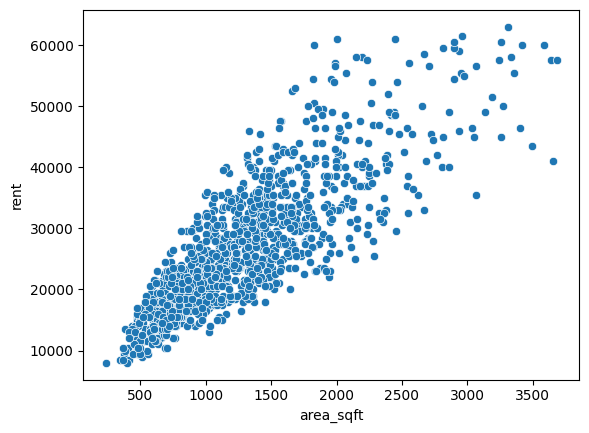

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["area_sqft"], y=df["rent"])
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Features (everything except rent)
X = df.drop("rent", axis=1)

# Target
y = df["rent"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Score
r2_score(y_test, y_pred)

0.9323180421893286

In [9]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

r2_score(y_test, y_pred_rf)

0.9090306617261391

In [10]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
scores, scores.mean()

(array([0.92519098, 0.92565821, 0.92162589, 0.92799033, 0.93624508]),
 np.float64(0.9273420976227265))

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    results[name] = {
        "mean_r2": scores.mean(),
        "std": scores.std()
    }

for model in results:
    print(model)
    print("Mean R2:", round(results[model]["mean_r2"], 4))
    print("Std Dev:", round(results[model]["std"], 4))
    print("-----")

c:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.803e+09, tolerance: 1.106e+07
  model = cd_fast.enet_coordinate_descent(
c:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.648e+09, tolerance: 1.064e+07
  model = cd_fast.enet_coordinate_descent(
c:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

Linear Regression
Mean R2: 0.9273
Std Dev: 0.0049
-----
Ridge
Mean R2: 0.9228
Std Dev: 0.0075
-----
Lasso
Mean R2: 0.9257
Std Dev: 0.0073
-----
Random Forest
Mean R2: 0.9043
Std Dev: 0.0127
-----


In [12]:
best_model = max(results, key=lambda x: results[x]['mean_r2'])
print("Best Model:", best_model)
print("R2:", results[best_model]['mean_r2'])

Best Model: Linear Regression
R2: 0.9273420976227265


In [16]:
import folium
from sklearn.linear_model import LinearRegression

# Train final model on full data
model = LinearRegression()
model.fit(X, y)

# Predict rent
df['predicted_rent'] = model.predict(X)

# Create base map (centered around Bhubaneswar)
map_center = [df['latitude'].mean(), df['longitude'].mean()]
m = folium.Map(
    location=map_center,
    zoom_start=12,
    tiles='CartoDB positron'  # 👈 change this
)

# Add colored points to map
for _, row in df.iterrows():
    
    # Color logic
    if row['predicted_rent'] < 15000:
        color = 'green'
    elif row['predicted_rent'] < 30000:
        color = 'orange'
    else:
        color = 'red'
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        popup=f"Predicted Rent: ₹{int(row['predicted_rent'])}",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(m)

m
m.save("map.html")